# the driver game: random vs optimal

a cab ride is revenue plus relocation — it moves the driver somewhere new, into a new menu of fares. this notebook solves the full dynamic program on the gurgaon grid (207 zones x 48 half-hour slots) and compares a driver who takes random rides against one who plays the optimal policy.

model: at each state (zone, slot) the driver waits or serves any ride; a ride pays its fare and occupies trip time + 10 min overhead. deadheading is omitted — with a ride always available it is strictly dominated (serving the same route earns the fare instead of burning fuel). terminal value is zero at day's end.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(0)

## build the city tensors

price[t, o, d] and trip[t, o, d] — fare and minutes for every slot, origin, destination

In [2]:
df = pd.read_parquet("city_grid.parquet")

hexes = sorted(df.from_id.unique())
names = df.drop_duplicates("from_id").set_index("from_id")["from_name"].to_dict()
idx = {h: i for i, h in enumerate(hexes)}
n, T = len(hexes), 48

t_arr = (df.slot.str[:2].astype(int) * 2 + (df.slot.str[3:] == "30")).values
o_arr = df.from_id.map(idx).values
d_arr = df.to_id.map(idx).values

price = np.zeros((T, n, n))
trip = np.zeros((T, n, n))
price[t_arr, o_arr, d_arr] = df.price.values
trip[t_arr, o_arr, d_arr] = df.trip_min.values

print(f"{n} zones, {T} slots, {len(df):,} rides loaded")

207 zones, 48 slots, 2,046,816 rides loaded


## solve the bellman equation

backward induction from 23:30 to 00:00. V[o, t] = best earnings still collectable from zone o at slot t

In [3]:
KAPPA = 10  # minutes of overhead per ride (pickup + finding the next passenger)

busy = np.ceil((trip + KAPPA) / 30).astype(int).clip(min=1)  # slots occupied per ride
pad = busy.max() + 1
V = np.zeros((n, T + pad))          # value; zero beyond end of day
best_dest = np.full((n, T), -1)     # -1 means wait

cols = np.arange(n)[None, :]
for t in range(T - 1, -1, -1):
    cand = price[t] + V[cols, t + busy[t]]      # fare + value at destination on arrival
    np.fill_diagonal(cand, -np.inf)             # no ride to yourself
    ride_val, ride_arg = cand.max(1), cand.argmax(1)
    wait_val = V[:, t + 1]
    take = ride_val > wait_val
    V[:, t] = np.where(take, ride_val, wait_val)
    best_dest[take, t] = ride_arg[take]

print(f"a perfectly-placed driver at 00:00 can still earn up to {V[:, 0].max():,.0f} inr")
print(f"waits in the optimal policy: {(best_dest == -1).mean() * 100:.0f}% of states")

a perfectly-placed driver at 00:00 can still earn up to 13,704 inr
waits in the optimal policy: 0% of states


## simulate a shift

both drivers start at the same zone at 8am and work until the day ends. the optimal driver follows the policy; the random driver accepts a uniformly random ride every time

In [4]:
START_T = 16  # 08:00
start_hex = int(np.argsort(V[:, START_T])[n // 2])  # a median-value starting zone
print(f"start: {names[hexes[start_hex]]}")

# optimal driver: follow the policy
h, t, cum = start_hex, START_T, 0.0
opt_path = [(t, 0.0)]
opt_rides = []
while t < T:
    d = best_dest[h, t]
    if d == -1:
        t += 1
    else:
        cum += price[t, h, d]
        opt_rides.append((t, names[hexes[h]], names[hexes[d]], price[t, h, d]))
        t += busy[t, h, d]
        h = d
    opt_path.append((min(t, T), cum))
opt_total = cum

# random driver: accept a uniformly random ride, 1000 simulated days
rand_totals, rand_paths = [], []
for sim in range(1000):
    h, t, cum = start_hex, START_T, 0.0
    path = [(t, 0.0)]
    while t < T:
        d = int(rng.integers(n - 1))
        d = d + 1 if d >= h else d
        cum += price[t, h, d]
        t += busy[t, h, d]
        h = d
        path.append((min(t, T), cum))
    rand_totals.append(cum)
    if sim < 30:
        rand_paths.append(path)
rand_totals = np.array(rand_totals)

print(f"optimal: {opt_total:,.0f} inr in {len(opt_rides)} rides")
print(f"random : {rand_totals.mean():,.0f} inr on average — optimal earns {opt_total / rand_totals.mean():.2f}x more")

start: South City I
optimal: 8,937 inr in 32 rides
random : 3,502 inr on average — optimal earns 2.55x more


## the day, side by side

cumulative earnings through the shift — thin lines are 30 random days

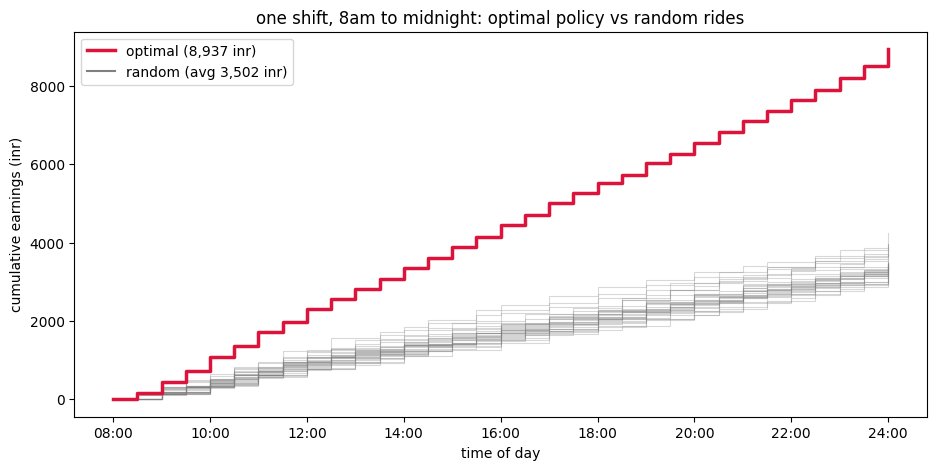

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for path in rand_paths:
    ts, cs = zip(*path)
    ax.step(ts, cs, where="post", color="grey", alpha=0.3, lw=0.8)
ts, cs = zip(*opt_path)
ax.step(ts, cs, where="post", color="crimson", lw=2.5, label=f"optimal ({opt_total:,.0f} inr)")
ax.step([], [], color="grey", label=f"random (avg {rand_totals.mean():,.0f} inr)")
ax.set_xticks(range(16, 49, 4), [f"{h:02d}:00" for h in range(8, 25, 2)])
ax.set_xlabel("time of day")
ax.set_ylabel("cumulative earnings (inr)")
ax.legend()
ax.set_title("one shift, 8am to midnight: optimal policy vs random rides");

## the distribution

1000 random days vs the optimal ceiling — the gap is the value of knowing where to be

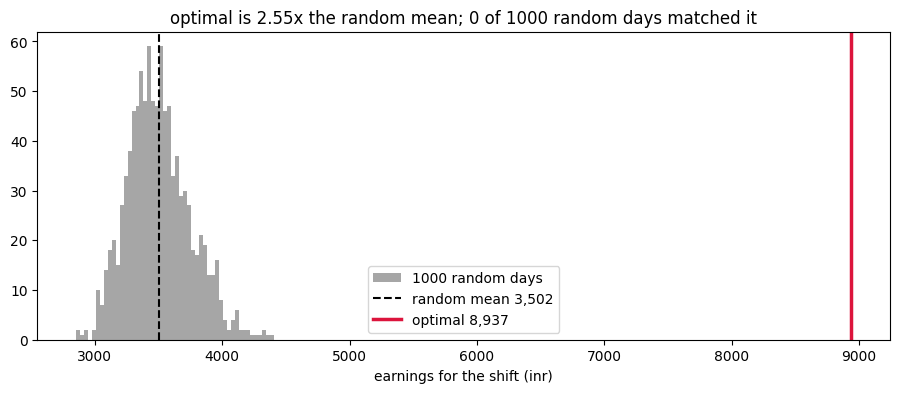

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(rand_totals, bins=50, color="grey", alpha=0.7, label="1000 random days")
ax.axvline(rand_totals.mean(), color="black", ls="--", label=f"random mean {rand_totals.mean():,.0f}")
ax.axvline(opt_total, color="crimson", lw=2.5, label=f"optimal {opt_total:,.0f}")
ax.set_xlabel("earnings for the shift (inr)")
ax.legend()
beat = (rand_totals >= opt_total).sum()
ax.set_title(f"optimal is {opt_total / rand_totals.mean():.2f}x the random mean; {beat} of 1000 random days matched it");

## where to be: the value surface

V(zone, time) with zones sorted by their day-average value — bright rows are the places worth being, and the fade to the right is the day running out

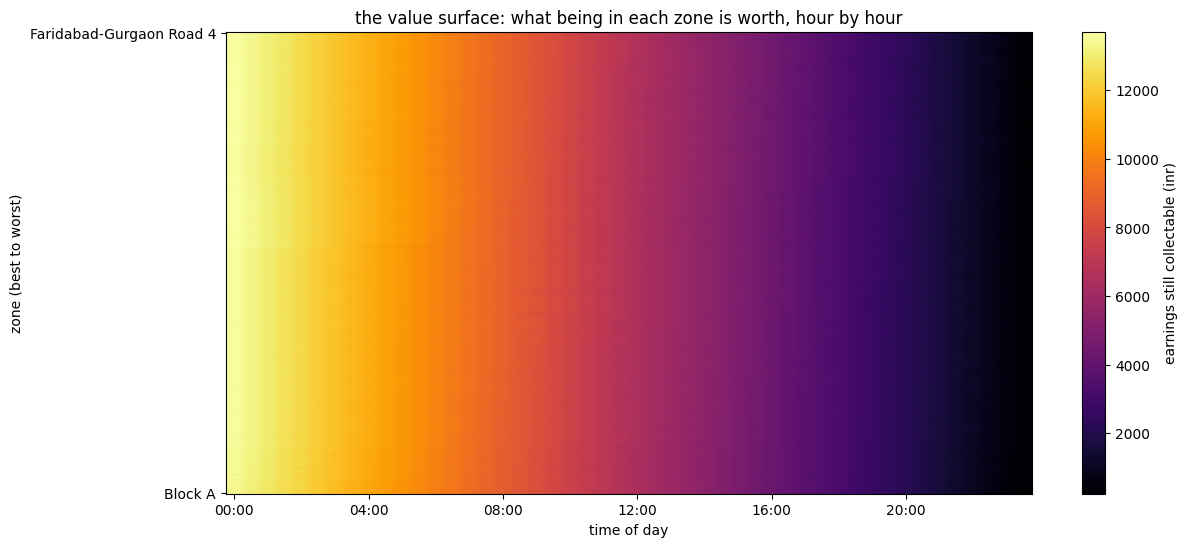

In [7]:
order = np.argsort(V[:, :T].mean(1))[::-1]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(V[order, :T], aspect="auto", cmap="inferno")
ax.set_xticks(range(0, 48, 8), [f"{h:02d}:00" for h in range(0, 24, 4)])
ax.set_yticks([0, n - 1], [names[hexes[order[0]]], names[hexes[order[-1]]]])
ax.set_xlabel("time of day")
ax.set_ylabel("zone (best to worst)")
fig.colorbar(im, label="earnings still collectable (inr)")
ax.set_title("the value surface: what being in each zone is worth, hour by hour");

## the fare is not the value

for every possible ride at 6pm: sticker fare vs positional premium (what the destination does to your future, holding time constant). rides below zero premium are traps — big fares that exile you from the money

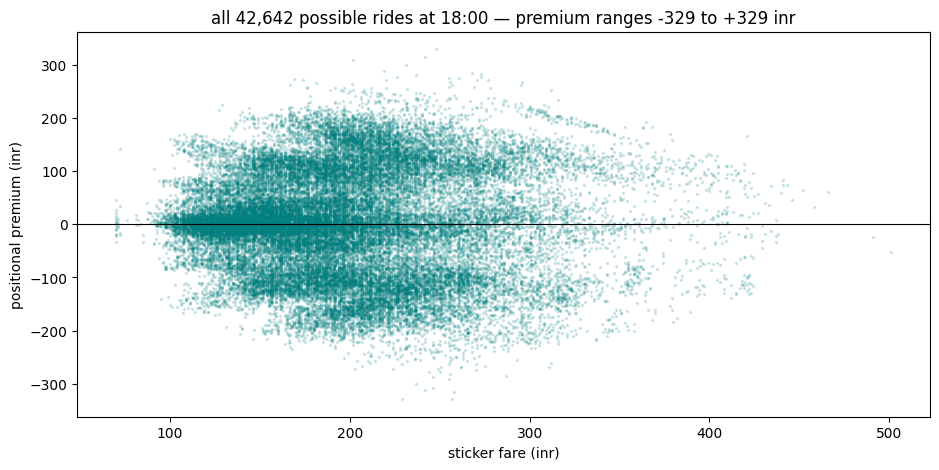

In [8]:
t6 = 36  # 18:00
arr = t6 + busy[t6]
premium = V[cols, arr] - V[np.arange(n)[:, None], arr]  # V(dest, t') - V(origin, t')
mask = ~np.eye(n, dtype=bool)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(price[t6][mask], premium[mask], s=2, alpha=0.15, color="teal")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("sticker fare (inr)")
ax.set_ylabel("positional premium (inr)")
ax.set_title(f"all {mask.sum():,} possible rides at 18:00 — premium ranges "
             f"{premium[mask].min():,.0f} to +{premium[mask].max():,.0f} inr");

## optimal vs profit-maximizing, from every zone

the greedy driver always takes the ride with the best fare per minute of busy time — pure hustle, no positioning. simulated from all 207 starting zones and compared to the optimal ceiling V(zone, 8am). the gap is what strategy earns over hustle

In [9]:
rate = price / (busy * 30)  # fare per minute of occupied time
for t in range(T):
    np.fill_diagonal(rate[t], -np.inf)

greedy_totals = np.zeros(n)
for start in range(n):
    h, t, cum = start, START_T, 0.0
    while t < T:
        d = int(rate[t, h].argmax())
        cum += price[t, h, d]
        t += busy[t, h, d]
        h = d
    greedy_totals[start] = cum

opt_totals = V[:, START_T]
gap = opt_totals / greedy_totals

print(f"optimal : {opt_totals.mean():,.0f} inr avg across all starts")
print(f"greedy  : {greedy_totals.mean():,.0f} inr avg — optimal earns {gap.mean():.2f}x more")
print(f"gap range: {gap.min():.2f}x (best case for hustle) to {gap.max():.2f}x (worst)")

optimal : 8,930 inr avg across all starts
greedy  : 7,818 inr avg — optimal earns 1.14x more
gap range: 1.10x (best case for hustle) to 1.24x (worst)


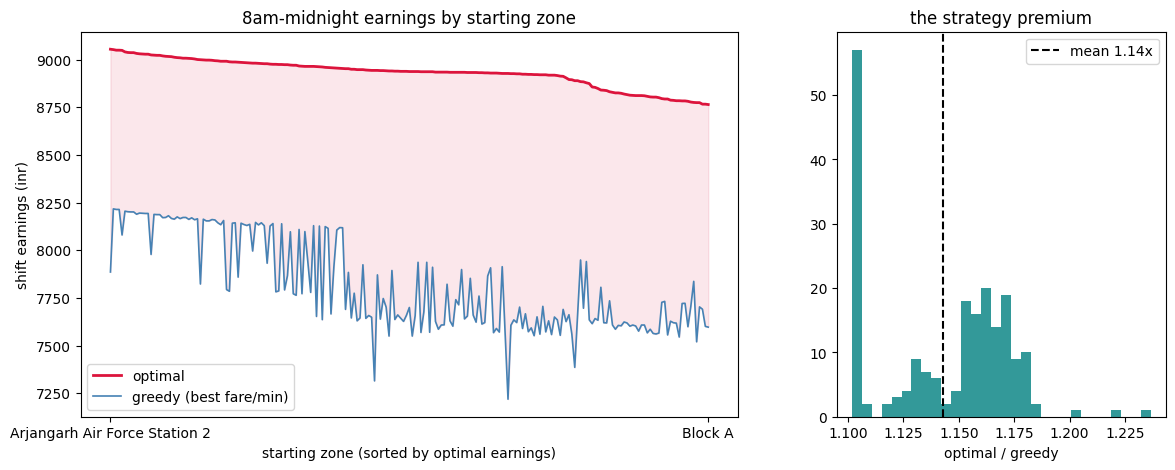

In [10]:
order2 = np.argsort(opt_totals)[::-1]

fig, (a, b) = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[2, 1])
a.plot(opt_totals[order2], color="crimson", lw=2, label="optimal")
a.plot(greedy_totals[order2], color="steelblue", lw=1.2, label="greedy (best fare/min)")
a.fill_between(range(n), greedy_totals[order2], opt_totals[order2], color="crimson", alpha=0.1)
a.set_xticks([0, n - 1], [names[hexes[order2[0]]], names[hexes[order2[-1]]]])
a.set_xlabel("starting zone (sorted by optimal earnings)")
a.set_ylabel("shift earnings (inr)")
a.legend()
a.set_title("8am-midnight earnings by starting zone")

b.hist(gap, bins=30, color="teal", alpha=0.8)
b.axvline(gap.mean(), color="black", ls="--", label=f"mean {gap.mean():.2f}x")
b.set_xlabel("optimal / greedy")
b.legend()
b.set_title("the strategy premium");

## minute-level optimization

the 30-minute slots above waste time: a 12-minute ride and a 28-minute ride both consumed a full slot, so leftover minutes vanished and quick hops looked artificially cheap. here the same bellman equation is solved on a minute grid — 207 zones x 1440 minutes — where a ride occupies exactly its trip time + 10 min overhead. fares and trip times still come from the ride's 30-min departure slot

In [11]:
M = 1440  # minutes in the day
busy_min = np.ceil(trip + KAPPA).astype(int).clip(min=1)  # (48, n, n) minutes per ride
pad_m = busy_min.max() + 1

Vm = np.zeros((n, M + pad_m))
best_dest_m = np.full((n, M), -1, dtype=np.int16)

for t in range(M - 1, -1, -1):
    s = t // 30
    cand = price[s] + Vm[cols, t + busy_min[s]]
    np.fill_diagonal(cand, -np.inf)
    ride_val, ride_arg = cand.max(1), cand.argmax(1)
    wait_val = Vm[:, t + 1]
    take = ride_val > wait_val
    Vm[:, t] = np.where(take, ride_val, wait_val)
    best_dest_m[take, t] = ride_arg[take]

START_M = 480  # 08:00
opt_m = Vm[:, START_M]
print(f"minute-level optimal: {opt_m.mean():,.0f} inr avg across starts "
      f"(slot-level was {opt_totals.mean():,.0f} — rounding cost {opt_m.mean() / opt_totals.mean() - 1:+.0%})")

minute-level optimal: 10,812 inr avg across starts (slot-level was 8,930 — rounding cost +21%)


In [12]:
# greedy at minute resolution too, for a fair fight
rate_m = price / np.maximum(busy_min, 1)
for s in range(T):
    np.fill_diagonal(rate_m[s], -np.inf)

greedy_m = np.zeros(n)
for start in range(n):
    h, t, cum = start, START_M, 0.0
    while t < M:
        s = t // 30
        d = int(rate_m[s, h].argmax())
        cum += price[s, h, d]
        t += busy_min[s, h, d]
        h = d
    greedy_m[start] = cum

# replay the minute-optimal policy from the same start zone as before
h, t, cum, rides = start_hex, START_M, 0.0, 0
while t < M:
    d = best_dest_m[h, t]
    if d == -1:
        t += 1
    else:
        cum += price[t // 30, h, d]
        rides += 1
        t += busy_min[t // 30, h, d]
        h = d

print(f"from {names[hexes[start_hex]]}: {cum:,.0f} inr in {rides} rides "
      f"(slot-level managed {opt_total:,.0f} in {len(opt_rides)})")
print(f"greedy minute-level: {greedy_m.mean():,.0f} inr avg — strategy premium now {(opt_m / greedy_m).mean():.2f}x")

from South City I: 10,847 inr in 45 rides (slot-level managed 8,937 in 32)
greedy minute-level: 10,304 inr avg — strategy premium now 1.05x


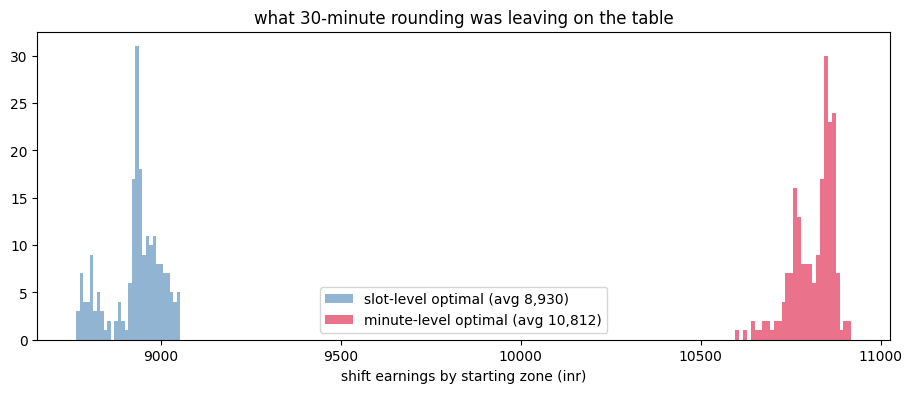

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(opt_totals, bins=30, alpha=0.6, color="steelblue", label=f"slot-level optimal (avg {opt_totals.mean():,.0f})")
ax.hist(opt_m, bins=30, alpha=0.6, color="crimson", label=f"minute-level optimal (avg {opt_m.mean():,.0f})")
ax.set_xlabel("shift earnings by starting zone (inr)")
ax.legend()
ax.set_title("what 30-minute rounding was leaving on the table");